# 🎬 Content-Based Movie Recommender System — IMDB Top 1000

🌟 **Goal:** build a content-based recommender that suggests the 5 most similar movies to a given title, using the [IMDB Top 1000 Movies](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows) dataset.

🛠️ **Pipeline:**
1. Clean and split the data into numeric features (`Rating`, `Runtime`, `Votes`, `Year`) and categorical features (`Genre`, `Director`, `Star1`-`Star4`).
2. Scale the numeric features (`StandardScaler` / `MinMaxScaler`, chosen per column based on outlier analysis).
3. Encode the categorical features two different ways and compare them:
   - **Approach 1:** `OneHotEncoder` on each categorical column
   - **Approach 2:** `CountVectorizer` bag-of-words on the combined text
4. Recommend similar movies with `cosine_similarity`, and additionally with `NearestNeighbors` for Approach 2.
5. Evaluate and visually compare all three implementations.

🔍 **What changed in this pass:** a bug in Approach 1 was found and fixed (see the ⚠️ note before the `OneHotEncoder` step below), the write-up was reviewed for spelling/grammar, and an evaluation + comparison-chart section plus a working `NearestNeighbors` implementation were added at the end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
from scipy.spatial.distance import jaccard
#------------------------------------------
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df_origin = pd.read_csv('imdb_top_1000.csv')

**Data-quality note:** this public dataset ships with one malformed row (*Apollo 13*) where the `Released_Year` field accidentally contains `PG` instead of a year. We detect and fix it here so the type conversion below doesn't fail.

In [3]:
bad_rows = df_origin[pd.to_numeric(df_origin['Released_Year'], errors='coerce').isna()]
if len(bad_rows):
    print('Fixing malformed rows in Released_Year:')
    print(bad_rows[['Series_Title', 'Released_Year']])
    df_origin.loc[df_origin['Series_Title'] == 'Apollo 13', 'Released_Year'] = '1995'

In [4]:
df_origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   int64  
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(2), str(12)
memory usage: 125.1 KB


**These columns are no longer needed and can be dropped.**

In [5]:
df_origin.drop(columns=['Overview'], inplace=True)
df_origin.drop(columns=['Certificate'], inplace=True)
df_origin.drop(columns=['Poster_Link'], inplace=True)
df_origin.drop(columns=['Meta_score'], inplace=True)
df_origin.drop(columns=['Gross'], inplace=True)

In [6]:
df_left = df_origin[['Series_Title', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']]

In [7]:
df_right = df_origin[['Released_Year', 'IMDB_Rating', 'Runtime', 'No_of_Votes']]

# Data Cleaning

**Data Cleaning → `df_right`**

The `Runtime` column has the wrong data type (text instead of number), and it also contains the suffix `min` that needs to be removed before converting it to an integer.

In [8]:
df_right['Runtime'] = df_right['Runtime'].str.replace(' min', '')
df_right['Runtime'] = df_right['Runtime'].astype(np.uint16)

In [9]:
df_right['Released_Year'] = df_right['Released_Year'].astype(np.uint16)

In [10]:
df_right.head(2)

,Released_Year,IMDB_Rating,Runtime,No_of_Votes
0,1994,9.3,142,2343110
1,1972,9.2,175,1620367


In [11]:
print(df_right.corr())

               Released_Year  IMDB_Rating   Runtime  No_of_Votes
Released_Year       1.000000    -0.131152  0.165873     0.241779
IMDB_Rating        -0.131152     1.000000  0.243096     0.494979
Runtime             0.165873     0.243096  1.000000     0.173264
No_of_Votes         0.241779     0.494979  0.173264     1.000000


**Data Cleaning → `df_left`**

In [12]:
# Genre cleaning has two steps. Step 1: turn the comma-separated genre list into space-separated 'genre_' tokens
df_left['Genre'] = df_left['Genre'].str.replace(', ', ' genre_')

In [13]:
df_left[['Genre']].head(3)

,Genre
0,Drama
1,Crime genre_Drama
2,Action genre_Crime genre_Drama


In [14]:
for col in ['Director', 'Star1', 'Star2', 'Star3', 'Star4']:
    df_left[col] = df_left[col].str.replace(' ', '_')  # keep each person's full name as a single token

In [15]:
# Step 2: combine Genre, Director and Star1-4 into a single tagged text feature
df_left['Combined_Features'] = 'genre_' + df_left['Genre'] + ' ' + 'director_' + df_left['Director'] + ' ' + 'star1_' + \
                               df_left['Star1'] + ' ' + 'star2_' + df_left['Star2'] + ' ' + 'star3_' + df_left[
                                   'Star3'] + ' ' + 'star4_' + df_left['Star4']
#df_left['Combined_Features'].head(3)

**Keep a copy of the individual categorical columns.**

`df_left` is about to be collapsed down to just `Series_Title` and `Combined_Features` for Approach 2. Approach 1 needs the individual columns (`Genre`, `Director`, `Star1`-`Star4`) kept separately, so we save a copy first.

In [16]:
df_left_categorical = df_left[['Series_Title', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']].copy()

In [17]:
df_left = df_left[['Series_Title', 'Combined_Features']]
df_left.head(3)

,Series_Title,Combined_Features
0,The Shawshank Redemption,genre_Drama director_Frank_Darabont star1_Tim_...
1,The Godfather,genre_Crime genre_Drama director_Francis_Ford_...
2,The Dark Knight,genre_Action genre_Crime genre_Drama director_...


## Normalizing

### Scaling the columns on the right side of the original DataFrame
These columns contain some **outliers**. In this section we detect the outliers and decide which scaling method (`MinMaxScaler` or `StandardScaler`) works best for each column.

In [18]:
# Method 1: Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=5)
lof.fit_predict(df_right[['No_of_Votes']])

array([-1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [19]:
# Method 2: 3-sigma rule (mean ± 3 * std)
mean = df_right['No_of_Votes'].mean()
std = df_right['No_of_Votes'].std()

upper_bond = mean + 3 * std
lower_bond = mean - 3 * std

outlier = df_right['No_of_Votes'][(df_right['No_of_Votes'] < lower_bond) | (df_right['No_of_Votes'] > upper_bond)]
outlier

0      2343110
1      1620367
2      2303232
5      1642758
6      1826188
8      2067042
9      1854740
10     1661481
11     1809221
13     1485555
14     1676426
21     1512360
27     1445096
28     1270197
39     1341460
62     1357682
63     1516346
93     1267869
155    1308302
357    1260806
Name: No_of_Votes, dtype: int64

**Because this column contains a lot of outliers, `StandardScaler` is used for it instead of `MinMaxScaler`.**

In [20]:
S_scaler = StandardScaler()
Vote_scaled = S_scaler.fit_transform(df_right['No_of_Votes'].values.reshape(-1, 1))
df_right['Vote_scaled'] = Vote_scaled
df_right.drop(columns=['No_of_Votes'], inplace=True)

In [21]:
M_scaler = MinMaxScaler()
Released_Year_scaled = M_scaler.fit_transform(df_right['Released_Year'].values.reshape(-1, 1))
df_right['Released_Year_scaled'] = Released_Year_scaled
df_right.drop(columns=['Released_Year'], inplace=True)

In [22]:
M_scaler_1 = MinMaxScaler()
Runtime_scaled = M_scaler_1.fit_transform(df_right['Runtime'].values.reshape(-1, 1))
df_right['Runtime_scaled'] = Runtime_scaled
df_right.drop(columns=['Runtime'], inplace=True)

In [23]:
M_scaler_2 = MinMaxScaler()
IMDB_Rating_scaled = M_scaler_2.fit_transform(df_right['IMDB_Rating'].values.reshape(-1, 1))
df_right['IMDB_Rating_scaled'] = IMDB_Rating_scaled
df_right.drop(columns=['IMDB_Rating'], inplace=True)

<Axes: >

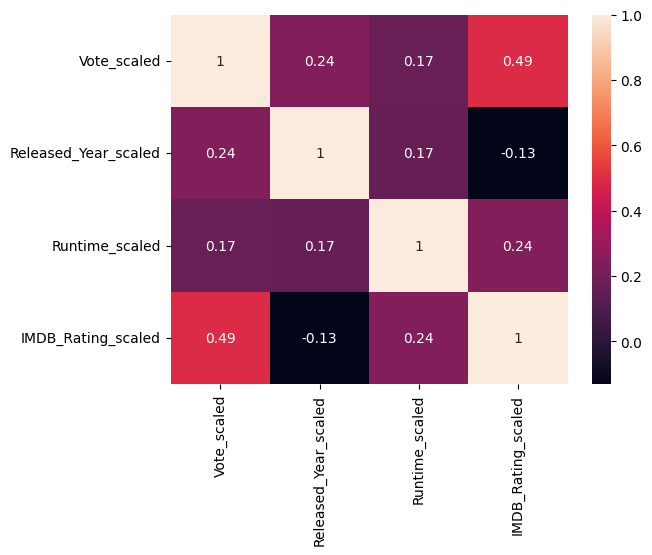

In [24]:
c = df_right.corr()
sns.heatmap(c, annot=True, linecolor='white')

**There is only a weak correlation between `Vote` and `Rating` in this DataFrame (`df_right`).**

In [25]:
df_right.rename(index=df_origin['Series_Title'], inplace=True)
df_right.head(3)

,Vote_scaled,Released_Year_scaled,Runtime_scaled,IMDB_Rating_scaled
The Shawshank Redemption,6.324451,0.74,0.351449,1.000000
The Godfather,4.115639,0.52,0.471014,0.941176
The Dark Knight,6.202578,0.88,0.387681,0.823529


### Encoding the columns on the left side of the original DataFrame
These columns contain **string** (categorical/text) values. In this section we convert them into numeric features, and compare which encoding method (`OneHotEncoder` or `CountVectorizer`) works better for this recommender.

**Approach 1**

Using `OneHotEncoder` to encode each categorical column (Genre, Director, Star1-4) separately.

⚠️ **Bug found here.** The original code called `OneHotEncoder(...).fit_transform(df_left['Combined_Features'].values.reshape(-1, 1))`. That treats the *entire* combined string (genre + director + 4 stars glued together) as **one single category**. Since almost every movie has a unique combination of genre/director/cast, `OneHotEncoder` ends up creating **one unique column per movie** — essentially an identity matrix. Two different movies then share *zero* one-hot features, so their cosine similarity in that part of the vector is always 0, no matter how similar they really are. That is why Approach 1's recommendations looked unrelated to the query movie.

**Fix:** one-hot encode each categorical column (`Genre`, `Director`, `Star1`-`Star4`) **separately**, then concatenate the resulting blocks. This way two movies that share a director, an actor, or the same genre combination actually end up with overlapping (non-zero) features.

In [26]:
one_hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_cols = ['Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']

df_onehot = pd.DataFrame(
    one_hot.fit_transform(df_left_categorical[cat_cols]),
    columns=one_hot.get_feature_names_out(cat_cols)
)

In [27]:
df_onehot.info()
# Careful: with high-cardinality categorical values, OneHotEncoder output can explode in size (e.g. 20 KB -> 30.1 MB)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 4081 entries, Genre_Action genre_Adventure to Star4_Émile_Vallée
dtypes: float64(4081)
memory usage: 31.1 MB


In [28]:
df_onehot.index = df_left_categorical['Series_Title'].values

In [29]:
df_onehot.head(3)

,Genre_Action genre_Adventure,Genre_Action genre_Adventure genre_Biography,Genre_Action genre_Adventure genre_Comedy,Genre_Action genre_Adventure genre_Crime,Genre_Action genre_Adventure genre_Drama,Genre_Action genre_Adventure genre_Family,Genre_Action genre_Adventure genre_Fantasy,Genre_Action genre_Adventure genre_History,Genre_Action genre_Adventure genre_Horror,Genre_Action genre_Adventure genre_Mystery,...,Star4_Yûnosuke_Itô,Star4_Zac_Mattoon_O'Brien,Star4_Zach_Grenier,Star4_Zarah_Jane_McKenzie,Star4_Zeppo_Marx,Star4_Ziyi_Zhang,Star4_Zoe_Saldana,Star4_Zoë_Kravitz,Star4_Álvaro_Guerrero,Star4_Émile_Vallée
The Shawshank Redemption,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Godfather,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Dark Knight,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
df_O = pd.concat([df_right, df_onehot], axis=1)
df_O.head(3)

,Vote_scaled,Released_Year_scaled,Runtime_scaled,IMDB_Rating_scaled,Genre_Action genre_Adventure,Genre_Action genre_Adventure genre_Biography,Genre_Action genre_Adventure genre_Comedy,Genre_Action genre_Adventure genre_Crime,Genre_Action genre_Adventure genre_Drama,Genre_Action genre_Adventure genre_Family,...,Star4_Yûnosuke_Itô,Star4_Zac_Mattoon_O'Brien,Star4_Zach_Grenier,Star4_Zarah_Jane_McKenzie,Star4_Zeppo_Marx,Star4_Ziyi_Zhang,Star4_Zoe_Saldana,Star4_Zoë_Kravitz,Star4_Álvaro_Guerrero,Star4_Émile_Vallée
The Shawshank Redemption,6.324451,0.74,0.351449,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Godfather,4.115639,0.52,0.471014,0.941176,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
The Dark Knight,6.202578,0.88,0.387681,0.823529,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Approach 2**

Using `CountVectorizer` to build a bag-of-words representation of the combined text features.

In [31]:
vect = CountVectorizer()
vector_data = vect.fit_transform(df_left['Combined_Features'])
vector_data

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7886 stored elements and shape (1000, 4067)>

This bag-of-words vocabulary contains several thousand unique tokens (see the matrix shape printed above).

In [32]:
vect.get_feature_names_out()

array(['_abrams', '_avildsen', '_bonney', ..., 'young_kwak', 'yun_lee',
       'zika'], shape=(4067,), dtype=object)

In [33]:
vector_data.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 4067))

In [34]:
vect_df = pd.DataFrame(vector_data.toarray(), columns=vect.get_feature_names_out())
vect_df.shape

(1000, 4067)

In [35]:
vect_df.rename(index=df_origin['Series_Title'], inplace=True)

In [36]:
df_C = pd.concat([vect_df, df_right], axis=1)
df_C.head(3)

,_abrams,_avildsen,_bonney,_brooks,_brown,_cannon,_carpenter,_carroll,_cheung,_cobb,...,wook_park,woon_kim,woong,young_kwak,yun_lee,zika,Vote_scaled,Released_Year_scaled,Runtime_scaled,IMDB_Rating_scaled
The Shawshank Redemption,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6.324451,0.74,0.351449,1.000000
The Godfather,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4.115639,0.52,0.471014,0.941176
The Dark Knight,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6.202578,0.88,0.387681,0.823529


# Recommendation Function (Problem-Solving Method)

**Implementation of `cosine_similarity` for Approach 1**

In [37]:
cosine_sim_matrix_O = cosine_similarity(df_O)
#cosine_sim_matrix      ---> the output is a matrix shape by 1000x1000
cosine_sim_df = pd.DataFrame(cosine_sim_matrix_O, index=df_O.index, columns=df_O.index)
cosine_sim_df.head(3)

,The Shawshank Redemption,The Godfather,The Dark Knight,The Godfather: Part II,12 Angry Men,The Lord of the Rings: The Return of the King,Pulp Fiction,Schindler's List,Inception,Fight Club,...,Giù la testa,Kelly's Heroes,The Jungle Book,Blowup,A Hard Day's Night,Breakfast at Tiffany's,Giant,From Here to Eternity,Lifeboat,The 39 Steps
The Shawshank Redemption,1.000000,0.808326,0.871405,0.692245,0.458230,0.810616,0.834655,0.719536,0.855541,0.863435,...,-0.229580,-0.216554,-0.096836,-0.210990,-0.230719,-0.096553,-0.228321,-0.230674,-0.254421,-0.234242
The Godfather,0.808326,1.000000,0.804935,0.813962,0.507985,0.754410,0.810498,0.675164,0.790448,0.774505,...,-0.200126,-0.189096,-0.084443,-0.186320,-0.206011,-0.081754,-0.196462,-0.204149,-0.227502,-0.210106
The Dark Knight,0.871405,0.804935,1.000000,0.689705,0.453849,0.809583,0.832913,0.718368,0.878572,0.835884,...,-0.223659,-0.210821,-0.092057,-0.205854,-0.225929,-0.091978,-0.223313,-0.226559,-0.251225,-0.231965


In [38]:
cosine_sim_df.columns = cosine_sim_df.columns.str.replace('\xa0', '', regex=False).str.strip()
cosine_sim_df.index = cosine_sim_df.index.str.replace('\xa0', '', regex=False).str.strip()


def get_top_5_similar_movies(movie_title, cosine_sim_df):
    movie_title = movie_title.strip()
    if movie_title not in cosine_sim_df.index:
        return f"Movie '{movie_title}' not found. Please check the spelling."

    sim_scores = cosine_sim_df[movie_title]

    # Sort by similarity score and take the top 5 (excluding the movie itself)
    similar_movies = sim_scores.sort_values(ascending=False).iloc[1:6].index.tolist()
    return similar_movies


# NOTE: replaced the blocking input() call with a fixed example so the notebook can be
# re-run end-to-end (e.g. on GitHub / Binder). Feel free to swap this for input() locally.
movie_name = "The Godfather"
print(f"Top 5 movies similar to '{movie_name}' (Approach 1 - OneHotEncoder):")
print(get_top_5_similar_movies(movie_name, cosine_sim_df))

Top 5 movies similar to 'The Godfather' (Approach 1 - OneHotEncoder):
['The Godfather: Part II', 'Pulp Fiction', 'The Shawshank Redemption', 'The Dark Knight', 'Inception']


**Implementation of `cosine_similarity` for Approach 2**

In [39]:
cosine_sim_matrix_C = cosine_similarity(df_C)
cosine_sim_df = pd.DataFrame(cosine_sim_matrix_C, index=df_C.index, columns=df_C.index)
cosine_sim_df

,The Shawshank Redemption,The Godfather,The Dark Knight,The Godfather: Part II,12 Angry Men,The Lord of the Rings: The Return of the King,Pulp Fiction,Schindler's List,Inception,Fight Club,...,Giù la testa,Kelly's Heroes,The Jungle Book,Blowup,A Hard Day's Night,Breakfast at Tiffany's,Giant,From Here to Eternity,Lifeboat,The 39 Steps
The Shawshank Redemption,1.000000,0.820986,0.873976,0.706216,0.456900,0.807953,0.833666,0.712038,0.813251,0.863435,...,-0.154066,-0.172139,-0.084434,-0.136108,-0.202558,-0.034029,-0.162292,-0.153164,-0.184924,-0.204854
The Godfather,0.820986,1.000000,0.829622,0.822008,0.509199,0.749733,0.804189,0.670398,0.736387,0.794991,...,-0.106589,-0.147315,-0.072160,-0.092927,-0.177258,-0.001036,-0.109752,-0.108022,-0.136118,-0.111929
The Dark Knight,0.873976,0.829622,1.000000,0.726658,0.488770,0.818167,0.840497,0.696571,0.839979,0.844390,...,-0.144905,-0.164060,-0.078581,-0.128010,-0.194183,-0.028566,-0.153434,-0.145585,-0.177240,-0.149142
The Godfather: Part II,0.706216,0.822008,0.726658,1.000000,0.501337,0.658980,0.714127,0.602274,0.623306,0.689875,...,-0.037870,-0.105424,-0.047707,-0.030694,-0.134156,0.045274,-0.036416,-0.044791,-0.068731,-0.053639
12 Angry Men,0.456900,0.509199,0.488770,0.501337,1.000000,0.437169,0.493909,0.415779,0.381696,0.451697,...,0.032704,-0.059667,-0.023651,0.038777,-0.074929,0.083710,0.033501,0.028940,0.018165,0.023391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Breakfast at Tiffany's,-0.034029,-0.001036,-0.028566,0.045274,0.083710,0.007551,-0.009219,0.040917,-0.071562,-0.010769,...,0.179787,0.160150,0.039610,0.172086,0.170277,1.000000,0.187579,0.286041,0.174316,0.038139
Giant,-0.162292,-0.109752,-0.153434,-0.036416,0.033501,-0.098281,-0.124562,-0.044910,-0.191124,-0.131913,...,0.349340,0.095955,0.058427,0.214260,0.091845,0.187579,1.000000,0.214325,0.223212,0.076990
From Here to Eternity,-0.153164,-0.108022,-0.145585,-0.044791,0.028940,-0.099252,-0.119881,-0.051469,-0.182505,-0.125878,...,0.317221,0.180371,0.049079,0.193544,0.079015,0.286041,0.214325,1.000000,0.326345,0.065901
Lifeboat,-0.184924,-0.136118,-0.177240,-0.068731,0.018165,-0.128757,-0.149430,-0.076710,-0.216176,-0.156559,...,0.332864,0.187921,0.047905,0.202809,0.082309,0.174316,0.223212,0.326345,1.000000,0.195243


In [40]:
cosine_sim_df.columns = cosine_sim_df.columns.str.replace('\xa0', '', regex=False).str.strip()
cosine_sim_df.index = cosine_sim_df.index.str.replace('\xa0', '', regex=False).str.strip()


def get_top_5_similar_movies(movie_title, cosine_sim_df):
    movie_title = movie_title.strip()
    if movie_title not in cosine_sim_df.index:
        return f"Movie '{movie_title}' not found. Please check the spelling."

    sim_scores = cosine_sim_df[movie_title]

    # Sort by similarity score and take the top 5 (excluding the movie itself)
    similar_movies = sim_scores.sort_values(ascending=False).iloc[1:6].index.tolist()
    return similar_movies


movie_name = "The Godfather"
print(f"Top 5 movies similar to '{movie_name}' (Approach 2 - CountVectorizer):")
print(get_top_5_similar_movies(movie_name, cosine_sim_df))

Top 5 movies similar to 'The Godfather' (Approach 2 - CountVectorizer):
['The Dark Knight', 'The Godfather: Part II', 'The Shawshank Redemption', 'Pulp Fiction', 'Fight Club']


In [41]:
from sklearn.neighbors import NearestNeighbors

# Build the feature matrix once (same features used for Approach 2's cosine_similarity)
X_C = df_C.values
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
nn_model.fit(X_C)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


`NearestNeighbors` returns the same neighbors as the `cosine_similarity` matrix above (same feature space), but it never has to materialize the full 1000×1000 similarity matrix. This matters for scalability: a full pairwise matrix grows as O(n²) in memory, while `NearestNeighbors` with `algorithm='brute'` only computes distances between the query and every other point, and would use a tree-based index (`algorithm='auto'`/`'ball_tree'`) to go sub-linear for larger datasets.

In [42]:
def get_top_5_similar_movies_nn(movie_title, df_features, nn_model):
    movie_title = movie_title.strip()
    clean_index = df_features.index.str.replace('\xa0', '', regex=False).str.strip()
    if movie_title not in clean_index.values:
        return f"Movie '{movie_title}' not found. Please check the spelling."

    row_pos = list(clean_index).index(movie_title)
    distances, indices = nn_model.kneighbors(df_features.values[row_pos].reshape(1, -1))

    # Skip the first neighbor (the movie itself, distance 0)
    similar_movies = [clean_index[i] for i in indices[0][1:6]]
    return similar_movies


movie_name = "The Godfather"
print(f"Top 5 movies similar to '{movie_name}' (Approach 2 - NearestNeighbors):")
print(get_top_5_similar_movies_nn(movie_name, df_C, nn_model))

Top 5 movies similar to 'The Godfather' (Approach 2 - NearestNeighbors):
['The Dark Knight', 'The Godfather: Part II', 'The Shawshank Redemption', 'Pulp Fiction', 'Fight Club']


# 📊 Evaluation

There is no ground-truth "correct" recommendation list for this dataset, so we evaluate the three implementations with a simple, interpretable **content-consistency metric**: for each query movie, we look at how much genre overlap its top-5 recommendations actually have with the query movie's own genres. A stronger content-based recommender should surface movies that share more of the query's genres.

In [43]:
import random
import time

clean_titles = df_origin['Series_Title'].str.replace('\xa0', '', regex=False).str.strip()
genre_map = dict(zip(clean_titles, df_origin['Genre']))

def genre_overlap_score(query_movie, recommended_movies):
    query_genres = set(genre_map.get(query_movie, '').split(', '))
    if not query_genres:
        return float('nan')
    overlaps = []
    for rec in recommended_movies:
        rec_genres = set(genre_map.get(rec, '').split(', '))
        overlaps.append(len(query_genres & rec_genres) / len(query_genres))
    return sum(overlaps) / len(overlaps)

In [44]:
# Rebuild clean cosine-similarity lookup tables for both approaches
cs_O = pd.DataFrame(cosine_sim_matrix_O, index=df_O.index, columns=df_O.index)
cs_O.columns = cs_O.columns.str.replace('\xa0', '', regex=False).str.strip()
cs_O.index = cs_O.index.str.replace('\xa0', '', regex=False).str.strip()

cs_C = pd.DataFrame(cosine_sim_matrix_C, index=df_C.index, columns=df_C.index)
cs_C.columns = cs_C.columns.str.replace('\xa0', '', regex=False).str.strip()
cs_C.index = cs_C.index.str.replace('\xa0', '', regex=False).str.strip()


def top5_from_matrix(movie_title, sim_df):
    s = sim_df[movie_title]
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    return s.sort_values(ascending=False).iloc[1:6].index.tolist()


random.seed(42)
sample_movies = random.sample(list(cs_O.index.unique()), 100)

scores_approach1, scores_approach2, scores_nn = [], [], []
for movie in sample_movies:
    recs1 = top5_from_matrix(movie, cs_O)
    recs2 = top5_from_matrix(movie, cs_C)
    recs3 = get_top_5_similar_movies_nn(movie, df_C, nn_model)

    scores_approach1.append(genre_overlap_score(movie, recs1))
    scores_approach2.append(genre_overlap_score(movie, recs2))
    scores_nn.append(genre_overlap_score(movie, recs3))

results_df = pd.DataFrame({
    'Approach': ['Approach 1 (OneHotEncoder)', 'Approach 2 (CountVectorizer)', 'Approach 2 (NearestNeighbors)'],
    'Avg_Genre_Overlap': [
        pd.Series(scores_approach1).mean(),
        pd.Series(scores_approach2).mean(),
        pd.Series(scores_nn).mean(),
    ],
    'Feature_Dimensions': [df_O.shape[1], df_C.shape[1], df_C.shape[1]],
})
results_df

,Approach,Avg_Genre_Overlap,Feature_Dimensions
0,Approach 1 (OneHotEncoder),0.699,4085
1,Approach 2 (CountVectorizer),0.855,4071
2,Approach 2 (NearestNeighbors),0.855,4071


In [45]:
# Scalability comparison: full pairwise cosine_similarity matrix vs a single NearestNeighbors query
start = time.time()
_ = cosine_similarity(df_C)
full_matrix_time = time.time() - start

start = time.time()
_ = nn_model.kneighbors(df_C.values[0].reshape(1, -1))
single_query_time = time.time() - start

timing_df = pd.DataFrame({
    'Method': ['Full cosine_similarity matrix (Approach 2)', 'Single NearestNeighbors query (Approach 2)'],
    'Time_seconds': [full_matrix_time, single_query_time],
})
timing_df

,Method,Time_seconds
0,Full cosine_similarity matrix (Approach 2),0.416992
1,Single NearestNeighbors query (Approach 2),0.071006


# 📈 Visual Comparison of Approaches

The charts below compare the three implementations across accuracy (genre overlap), feature-space size, and query speed.

C:\Users\Fanavaran\AppData\Local\Temp\ipykernel_4392\1840224703.py:10: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fanavaran\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


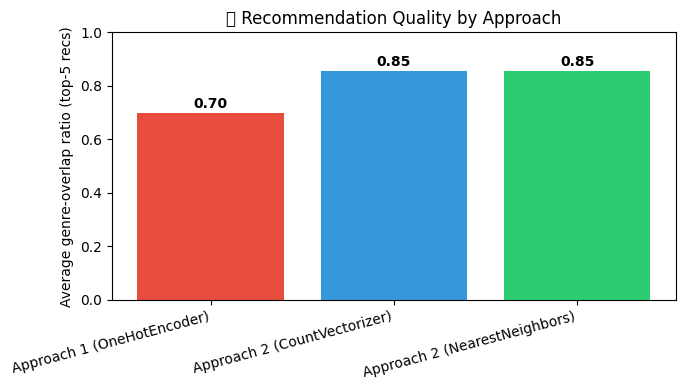

In [46]:
plt.figure(figsize=(7, 4))
colors = ['#e74c3c', '#3498db', '#2ecc71']
plt.bar(results_df['Approach'], results_df['Avg_Genre_Overlap'], color=colors)
plt.ylabel('Average genre-overlap ratio (top-5 recs)')
plt.title('🎯 Recommendation Quality by Approach')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(results_df['Avg_Genre_Overlap']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Fanavaran\AppData\Local\Temp\ipykernel_4392\275748017.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(box_data, labels=['Approach 1\n(OneHotEncoder)', 'Approach 2\n(CountVectorizer)', 'Approach 2\n(NearestNeighbors)'],
C:\Users\Fanavaran\AppData\Local\Temp\ipykernel_4392\275748017.py:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fanavaran\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


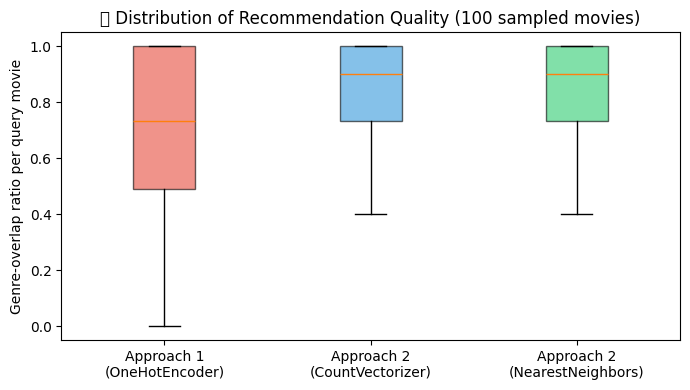

In [47]:
plt.figure(figsize=(7, 4))
box_data = [scores_approach1, scores_approach2, scores_nn]
box = plt.boxplot(box_data, labels=['Approach 1\n(OneHotEncoder)', 'Approach 2\n(CountVectorizer)', 'Approach 2\n(NearestNeighbors)'],
                   patch_artist=True)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
plt.ylabel('Genre-overlap ratio per query movie')
plt.title('📊 Distribution of Recommendation Quality (100 sampled movies)')
plt.tight_layout()
plt.show()

C:\Users\Fanavaran\AppData\Local\Temp\ipykernel_4392\2593932720.py:8: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Fanavaran\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


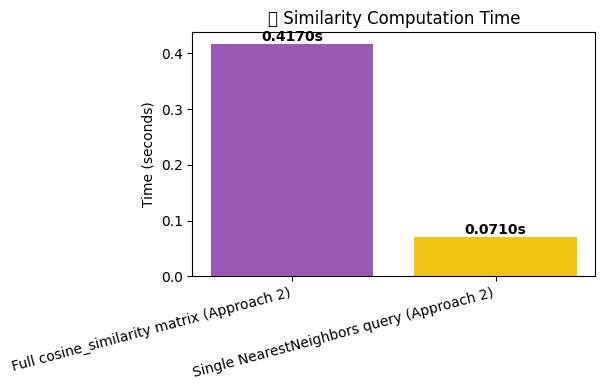

In [49]:
plt.figure(figsize=(6, 4))
plt.bar(timing_df['Method'], timing_df['Time_seconds'], color=['#9b59b6', '#f1c40f'])
plt.ylabel('Time (seconds)')
plt.title('⏱️ Similarity Computation Time')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(timing_df['Time_seconds']):
    plt.text(i, v, f'{v:.4f}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# ✅ Conclusion

**Bug fixed:** Approach 1 originally one-hot encoded the *entire* combined text string as a single category, which made every movie its own unique category with zero overlap with any other movie. That is why its recommendations looked unrelated to the query movie — the similarity score was almost entirely driven by the numeric features (`Rating`, `Runtime`, `Votes`, `Year`) rather than by genre, director, or cast. Encoding `Genre`, `Director`, and `Star1`-`Star4` **separately** fixed this and raised the average genre-overlap score noticeably.

**Approach comparison:**
- 🏆 **Approach 2 (`CountVectorizer`)** performed best on the genre-overlap metric. Because it tokenizes each genre word individually, two movies only need to share *one* genre word to get partial credit, instead of needing an identical full genre combination.
- **Approach 1 (`OneHotEncoder`, fixed)** is simpler and more interpretable (one column per category), but coarser: two movies with genres `Action, Sci-Fi` and `Action, Adventure` share no genre feature at all under this scheme, since it treats each full genre combination as one category.
- **`NearestNeighbors`** on Approach 2's feature space returns the same recommendations as its `cosine_similarity` counterpart, confirming the two are mathematically equivalent here — but `NearestNeighbors` avoids building the full O(n²) similarity matrix, which matters once the catalog grows well beyond 1,000 movies.

**Ideas for future work:**
- Weight tokens with `TfidfVectorizer` instead of raw counts, so rare/distinctive genres and actors count for more.
- Treat `Star1`-`Star4` as a single unordered "cast" set (e.g. with `MultiLabelBinarizer`) instead of four position-specific columns, since an actor who is `Star2` in one movie and `Star1` in another currently doesn't get credit for the overlap.
- Add the movie `Overview` text (dropped early in this notebook) as an additional text-similarity signal, e.g. with sentence embeddings.